In [1]:
MODEL_CLS = "dae"
NOISE = "01"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.deterministic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    noise=float(NOISE)*1e-1,
    **cfg.model.params,
)

model = autoencoder.dae.DenoisedAutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.1080
	BEST EPOCH: 27


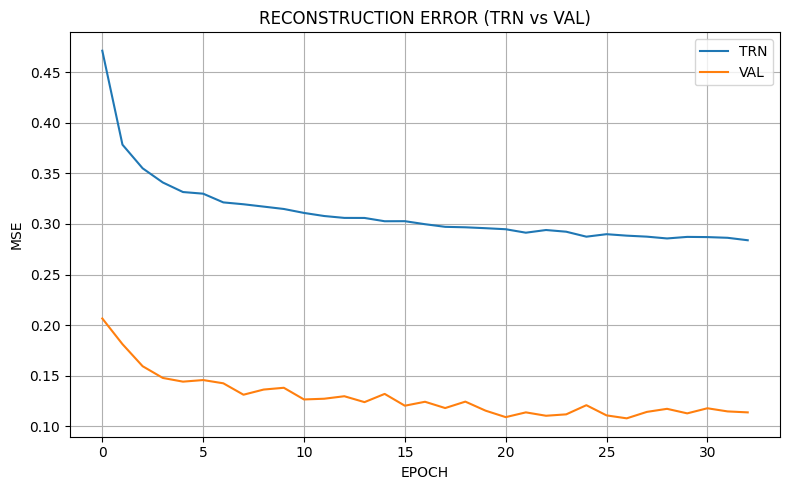

In [21]:
kwargs = dict(
    objs=(records["trn"], records["val"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="RECONSTRUCTION ERROR (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [15]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [16]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 407.37it/s]


In [17]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.254320,433,470,22,59,0.917683,0.951648,0.880081,0.914467
1,0.955,0.274310,433,476,16,59,0.923781,0.964365,0.880081,0.920298
2,0.960,0.298431,432,478,14,60,0.924797,0.968610,0.878049,0.921109
3,0.965,0.330073,429,481,11,63,0.924797,0.975000,0.871951,0.920601
4,0.970,0.365844,425,482,10,67,0.921748,0.977012,0.863821,0.916936
5,0.975,0.421515,418,483,9,74,0.915650,0.978923,0.849594,0.909684
6,0.980,0.505494,413,486,6,79,0.913618,0.985680,0.839431,0.906696
7,0.985,0.637241,410,490,2,82,0.914634,0.995146,0.833333,0.907080
8,0.990,0.889881,409,490,2,83,0.913618,0.995134,0.831301,0.905869
9,0.995,1.588424,397,492,0,95,0.903455,1.000000,0.806911,0.893138


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}_{NOISE}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)